## identify amplitude of the graph using 1d array input

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../datasets/train_waveforms.csv')

df.head()

,signal_0,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,...,signal_248,signal_249,signal_250,signal_251,signal_252,signal_253,signal_254,signal_255,label,label_name
0,0.387850,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,...,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,-0.239218,11,step_function
1,-2.105233,-2.107277,-2.106962,-2.104699,-2.103704,-2.101823,-2.097567,-2.091066,-2.083391,-2.075487,...,2.277827,2.302906,2.327990,2.353479,2.379064,2.409425,2.437787,2.465987,8,brownian_noise
2,-1.503394,1.333314,1.069614,-0.765695,-0.758472,-1.291105,0.795741,-0.285356,-0.348712,-0.969709,...,1.616518,-0.229811,0.235111,0.373192,-0.145190,1.098482,1.669057,-1.980697,6,white_noise
3,0.411003,0.488717,0.502179,0.504025,0.444583,0.377323,0.418636,0.500328,0.584794,0.622171,...,-1.341591,-1.452889,-1.510924,-1.399916,-1.359173,-1.264680,-1.379789,-1.374396,7,pink_noise
4,-0.491679,-0.520181,-0.548682,-0.577184,-0.605686,-0.634187,-0.662689,-0.691191,-0.719692,-0.748194,...,-0.735699,-0.764201,-0.792703,-0.821204,-0.849706,-0.827893,-0.799391,-0.770889,2,triangle


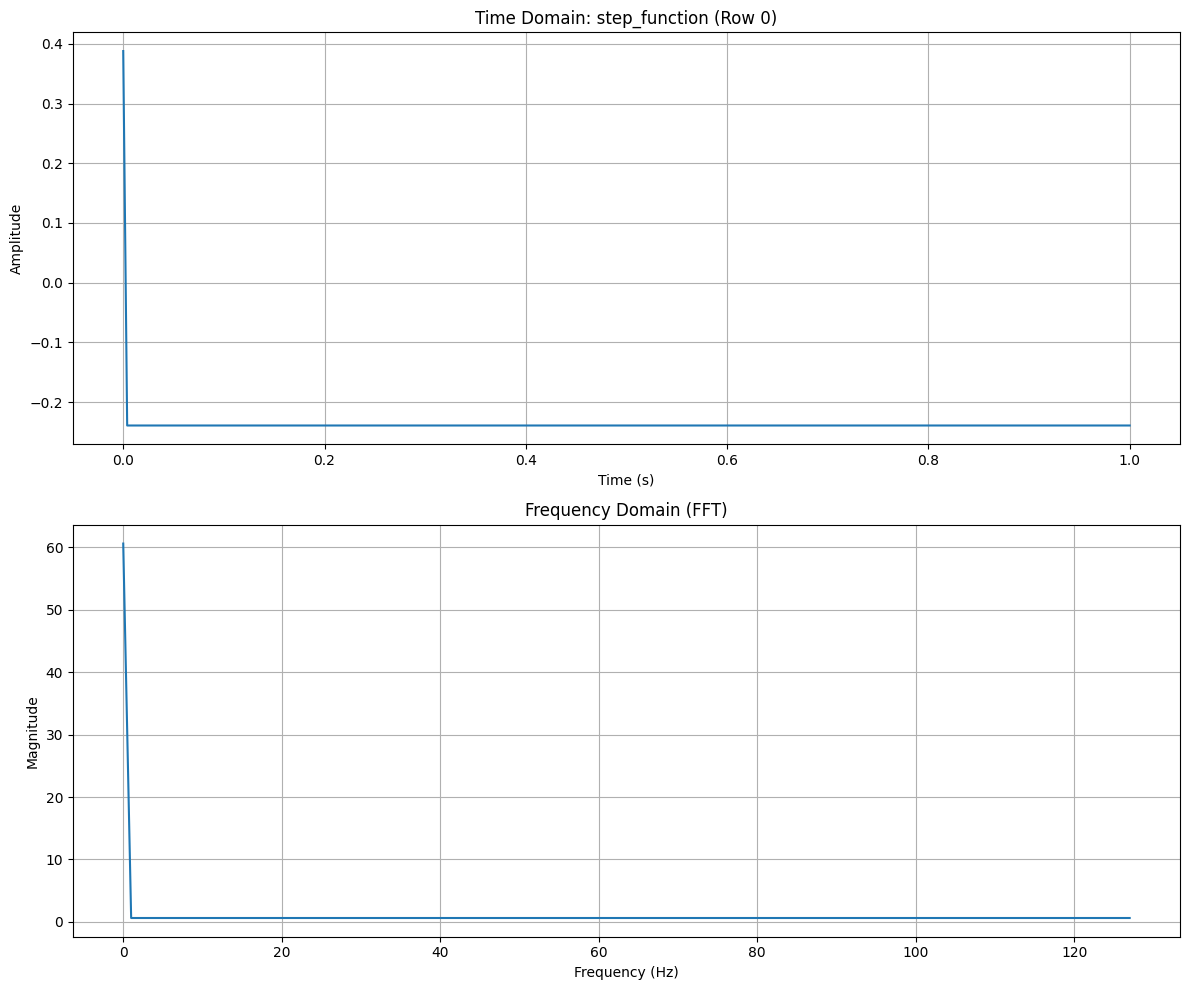

--- Signal Statistics ---
Peak-to-Peak: 0.6271
RMS: 0.2400
Mean: -0.2368
Std Dev: 0.0391
Dominant Frequency: 16.0000




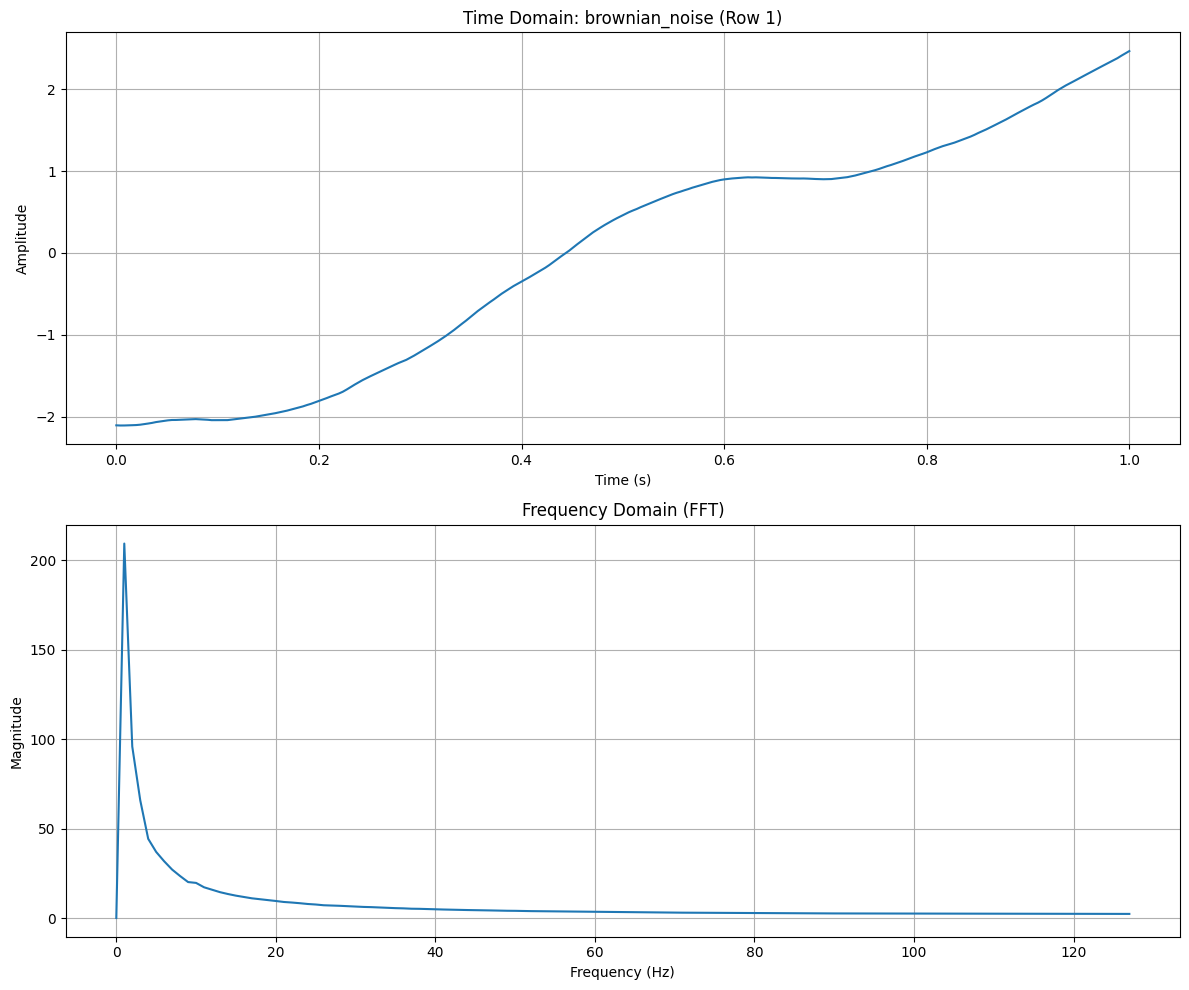

--- Signal Statistics ---
Peak-to-Peak: 4.5733
RMS: 1.4308
Mean: -0.0000
Std Dev: 1.4308
Dominant Frequency: 1.0000




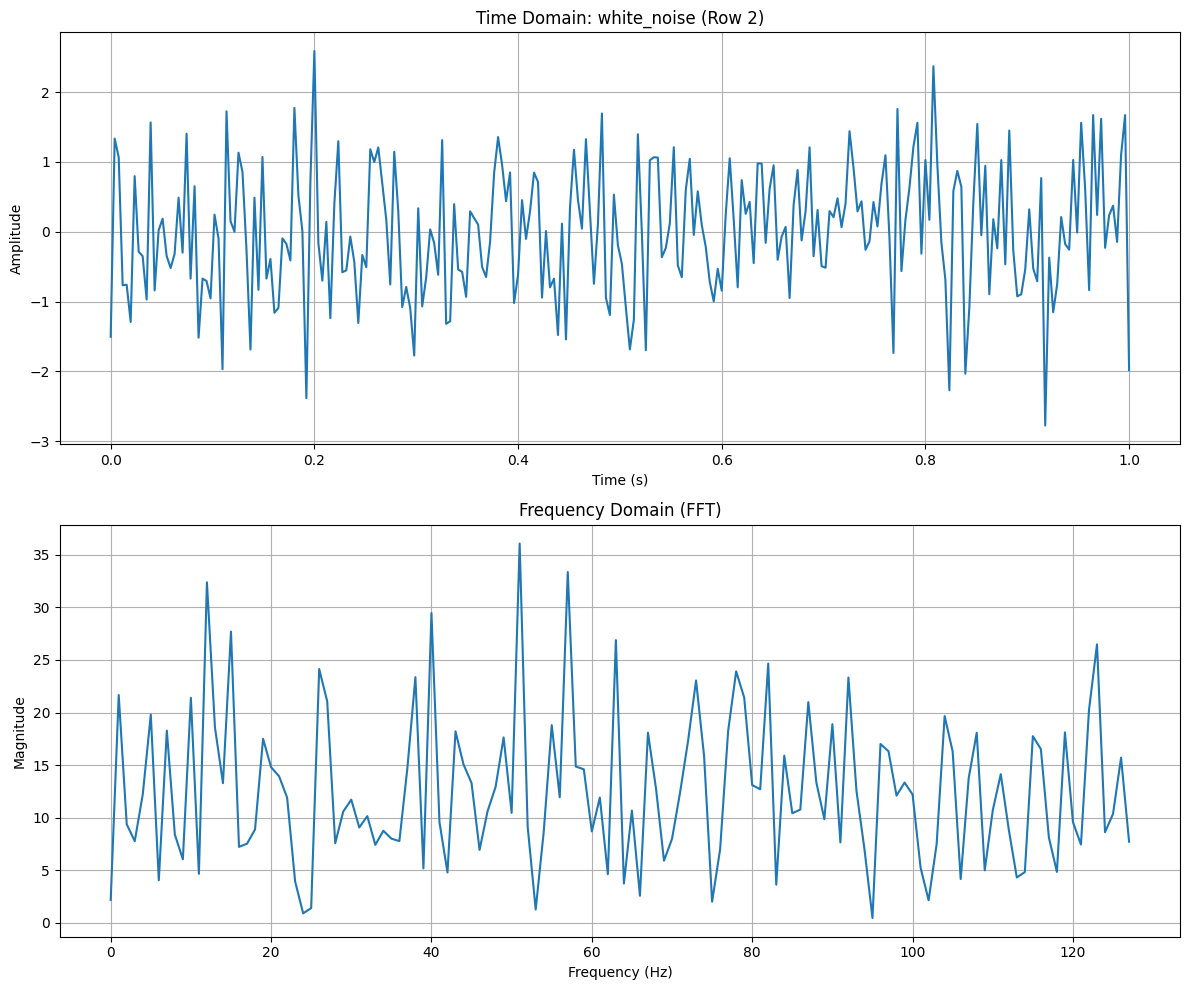

--- Signal Statistics ---
Peak-to-Peak: 5.3595
RMS: 0.9132
Mean: 0.0085
Std Dev: 0.9131
Dominant Frequency: 51.0000




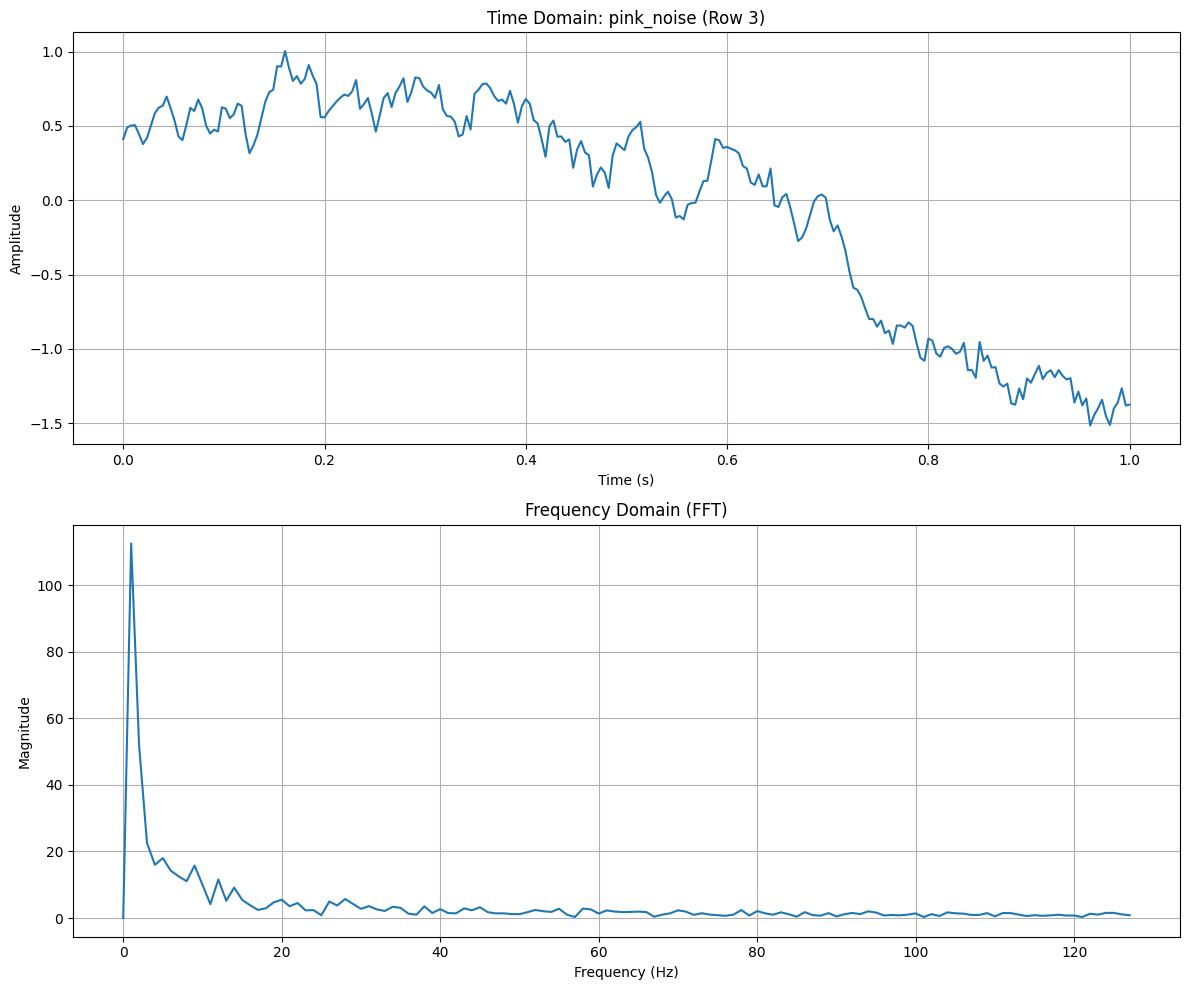

--- Signal Statistics ---
Peak-to-Peak: 2.5179
RMS: 0.7421
Mean: -0.0000
Std Dev: 0.7421
Dominant Frequency: 1.0000




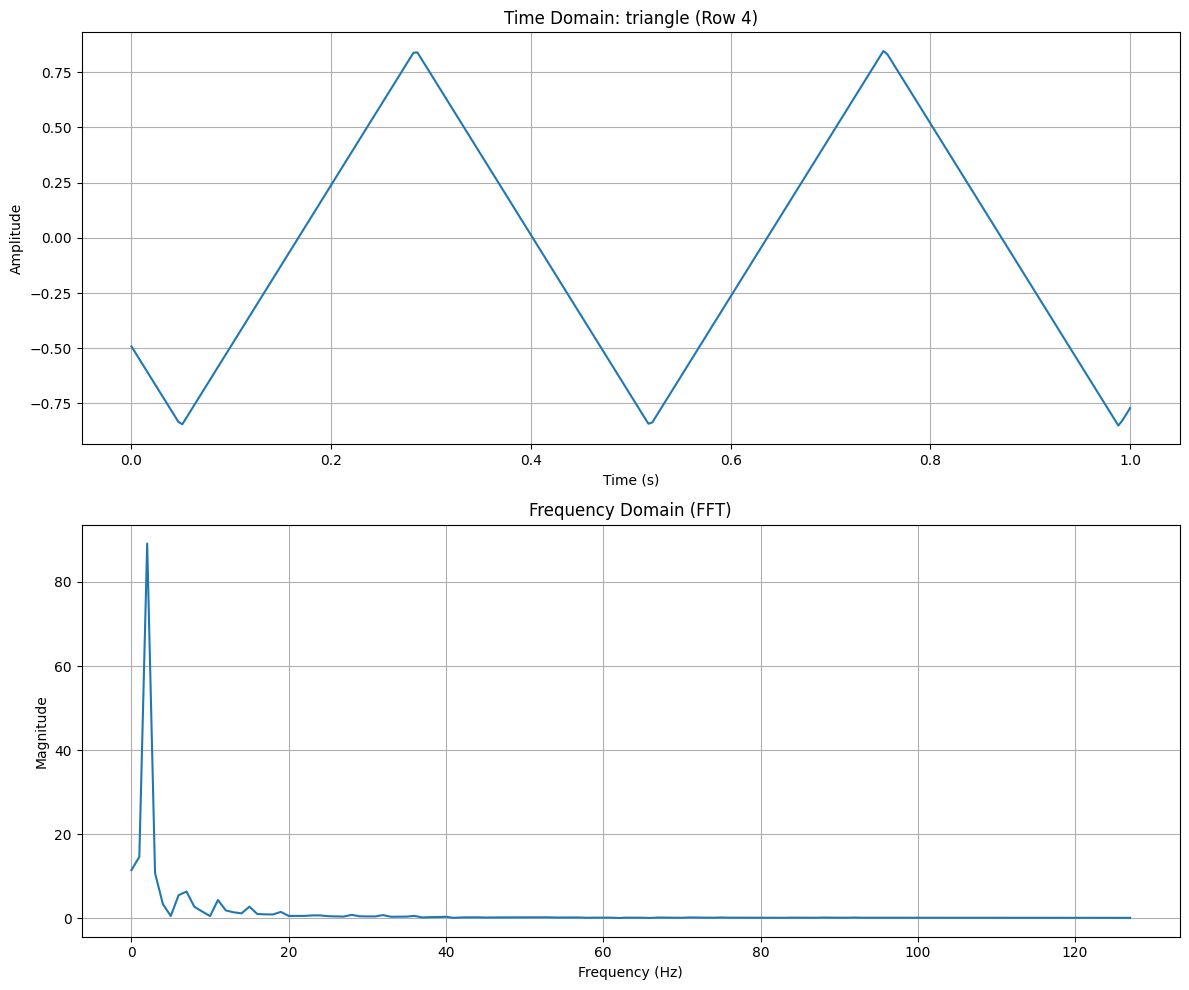

--- Signal Statistics ---
Peak-to-Peak: 1.6954
RMS: 0.5087
Mean: -0.0449
Std Dev: 0.5067
Dominant Frequency: 2.0000




In [2]:
from identify_amplitude_frequency import analyze_signal
import matplotlib.pyplot as plt
import numpy as np

# Function to plot and analyze a signal from the dataframe
def plot_signal_analysis(df, row_idx, sampling_rate=256):
    row = df.iloc[row_idx]
    signal_cols = [f'signal_{i}' for i in range(256)]
    signal = row[signal_cols].values
    label_name = row['label_name']
    
    stats, xf, yf = analyze_signal(signal, sampling_rate)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot Time Domain
    t = np.linspace(0, 1, len(signal))
    ax1.plot(t, signal)
    ax1.set_title(f"Time Domain: {label_name} (Row {row_idx})")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True)
    
    # Plot Frequency Domain
    ax2.plot(xf, yf)
    ax2.set_title(f"Frequency Domain (FFT)")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Magnitude")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("--- Signal Statistics ---")
    for key, value in stats.items():
        if isinstance(value, (float, np.float64)):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

# Analyze a few random signals
for i in range(5):
    plot_signal_analysis(df, i)
    print("\n" + "="*30 + "\n")